# Binary Classification

Let's solve this problem: 2D points $(x, y)$ with label 1, if inside the circle $x^2 + y^2 < 1$ else 0. We shall solve this problem in Pytorch for wase of implementation.

In [1]:
import torch
import random
import copy

import numpy as np
import matplotlib.pyplot as plt

import micrograd.nn as nn
from micrograd.engine import Value
import micrograd

from utils import generate_data, SGD, momentum, rmsprop, adam, tanhValue, sineValue
from train import simple_train

In [ ]:
# 1. Generate data and split it into train, test and validation set

# set random seed
np.random.seed(42)

# Let's generate random 2D points
n = 1000
data = (torch.rand(n, 2) * 2 - 1)*2 #torch.rand(n, 2) only creates random numbers in Q1, shift them to all Q's

# lets generate ground truth labels
mag = torch.sqrt(data[:, 0]**2 + data[:, 1]**2)
labels = (mag > 1.0).float()

dataset = torch.utils.data.TensorDataset(data, labels)

train_set, test_set, val_set = torch.utils.data.random_split(
    dataset, [600, 200, 200], generator=torch.Generator().manual_seed(42)
)

x_train, y_train = train_set[:][0], train_set[:][1].view(-1, 1)  # or iterate
x_test, y_test = test_set[:][0], test_set[:][1].view(-1, 1)

In [ ]:
# 2 Let's construct the network in Pytorch

"""
Input to the network is: 2D vectors
Output is 1D scalar value : either 1 or 0

Network is 2 inputs:
- 3 neurons in hidden (first) layer, 
- 3 in hidden (second) layer, 
- 5 neurons in output layer

The output neurons will emit the probabilities of each test sample falling in a particular category
"""

BinaryMLP = torch.nn.Sequential(
    torch.nn.Linear(2, 3),
    torch.nn.ReLU(),
    torch.nn.Linear(3, 3),
    torch.nn.ReLU(),
    torch.nn.Linear(3, 5)
)

# 3. define optimization algorithm and loss function type
optimizer = torch.optim.SGD(BinaryMLP.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

# 4. Train the network:
n_epochs = 10000
for epoch in range(n_epochs):
    optimizer.zero_grad() # grad zeroing step (otherwise gradients accumulate: remember micrograd)
    y_pred = BinaryMLP(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

In [ ]:
# 5. Inference
# first tell torch that this is test data,, don't compute gradients for this
with torch.no_grad():
    y_pred = BinaryMLP(x_test)
    predicted_labels = (torch.sigmoid(y_pred) > 0.5).float()

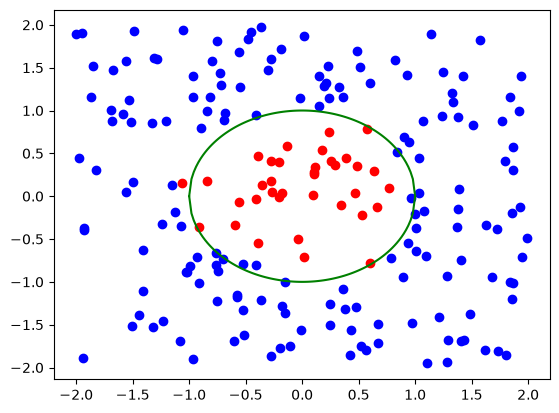

In [ ]:
# 6 plot
x_circle = np.linspace(-1, 1, 100)
y_circle= []
y_circle.extend([np.sqrt(1- x**2) for x in x_circle])
for i in range(len(x_test)):
    plt.scatter(x_test[i][0], x_test[i][1], 
                color='r' if predicted_labels[i].item() == 0 else "b")

plt.plot(x_circle, y_circle, color="g")
plt.plot(x_circle, [-1*y for y in y_circle], color="g")


# Multi-Category Classification

Now, lets try to categorize points into multiple categories than just 2. For this we shall take multiple concentric circles, and then classify points on the basis of their location.

In [ ]:
# set random seed
np.random.seed(42)

# 1. Generate data and split it into train, test and validation set  x \in [-20, +20] and y \in [-20, +20]
n = 1000
data = (torch.rand(n, 2) * 10 - 5)

# lets generate ground truth labels
mag = torch.sqrt(data[:, 0]**2 + data[:, 1]**2)
labels = torch.zeros_like(mag)

for i in range(len(labels)):
    if mag[i] < 1.0:
        labels[i] = 0
    elif mag[i] >= 1.0 and mag[i] < 2.0:
        labels[i] = 1
    elif mag[i]>=2.0 and mag[i]<3.0:
        labels[i] = 2
    elif mag[i]>=3.0 and mag[i]<4.0:
        labels[i] = 3
    else:
        labels[i] = 4

dataset = torch.utils.data.TensorDataset(data, labels)

train_set, test_set, val_set = torch.utils.data.random_split(
    dataset, [600, 200, 200], generator=torch.Generator().manual_seed(42)
)

x_train, y_train = train_set[:][0], train_set[:][1].view(-1, 1)  # or iterate
x_test, y_test = test_set[:][0], test_set[:][1].view(-1, 1)

# Upsampling --------------------------------------------------------------

# After generating x_train, y_train
# Find indices of class 0
class0_idx = (y_train == 0).nonzero(as_tuple=True)[0]

# Repeat them, say 10x
x_train = torch.cat([x_train, x_train[class0_idx].repeat(10, 1)])
y_train = torch.cat([y_train, y_train[class0_idx].repeat(10, 1)])

# -------------------------------------------------------------------------
# Comment this out to see changes in the Model predictions

## The science behind Cross Entropy Loss:

We built a dense: 2 (inputs) X 3 X 3 X 5 (outputs) with normal ReLU activations. And we are giving in 2D scalar inputs. Hence the output is going to be 5X1 vector. 

For example: [3.0, 2.4, 1.0, -2.0, 0.78]

These raw score mean nothing as such. When these are passed through softmax():

$$ P(i) = \frac{e^{z_i}}{\sum_{j=0}^{4} e^{z_j}} $$

See for yourself in the code cell below:

In [4]:
torch.softmax(torch.Tensor([3.0, 2.4, 1.0, -2.0, 0.78]), dim=0) 

tensor([0.5557, 0.3050, 0.0752, 0.0037, 0.0604])

You see that `softmax()` has this tendency to push everything into the [0, 1] range. So you see that the raw scores are normalized into probabilistic values. 

Now, what does `CrossEntropyLoss` do?
-  We already know what the correct category is: we provide that in the `y_test` data.
- The loss function then only computes the -log of the given class: which measures how "off" were the network predictions from the test data label

$$\text{Loss} = -\log(P(\text{true\_class}))$$

- Why $-\log$?: because if the model is confident (as in the cprrect answer is Class 2), and the model's computed probability is high for Class 2, then -log will reward it.

Take a look at how -log looks like:

Text(0, 0.5, 'Loss')

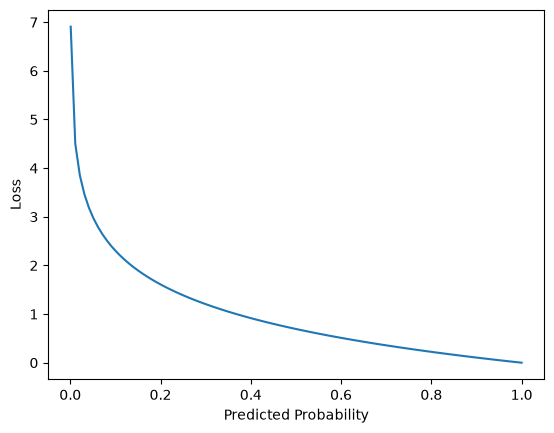

In [5]:
# remember the -log is only taken on probabilities
# so we can safely only consider [0, 1] to be the domain
xlog = np.linspace(0.001, 1, 100)
plt.plot(xlog, -1*np.log(xlog))
plt.xlabel("Predicted Probability")
plt.ylabel("Loss")

So the more the model is confident, the lower the loss is going to be. But we have many test samples in the test dataset right? And each sample creates a loss value...

`CrossEntropyLoss` averages all these loss values and then gives out the averaged loss, for the backpropagation to propagate through the network.

In [11]:
# 2: Setup network:

# Inputs are 2d vectors, outputs are scalar labels

MultiCategoryClassify = torch.nn.Sequential(torch.nn.Linear(2, 3), 
                                            torch.nn.ReLU(),
                                            torch.nn.Linear(3, 3),
                                            torch.nn.ReLU(),
                                            torch.nn.Linear(3, 5))

#3: Setup optimization routine and loss criterion
optimizer = torch.optim.SGD(MultiCategoryClassify.parameters(), lr=0.01)
loss_criterion = torch.nn.CrossEntropyLoss()

# 3.1 Cross entropy loss needs integers as indices in labels
y_train = y_train.view(-1).long()
y_test = test_set[:][1].view(-1).long()

# 4. Train the network:
n_epochs = 50000
for epoch in range(n_epochs):
    optimizer.zero_grad() # grad zeroing step (otherwise gradients accumulate: remember micrograd)
    y_pred = MultiCategoryClassify(x_train)
    loss = loss_criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

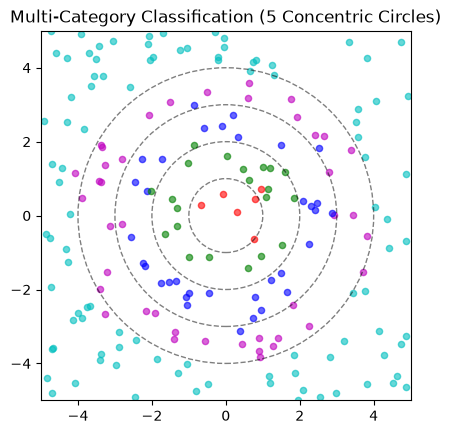

In [12]:
# 5. Inference
with torch.no_grad():
    y_pred = MultiCategoryClassify(x_test)
    predicted_labels = torch.argmax(y_pred, dim=1)

# 6. Plotting
colors = ['r', 'g', 'b', 'm', 'c']
for i in range(len(x_test)):
    plt.scatter(x_test[i][0], x_test[i][1], 
                color=colors[predicted_labels[i].item()], s=20, alpha=0.6)

# Draw circle boundaries
for r in [1, 2, 3, 4]:
    circle = plt.Circle((0, 0), r, color='k', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Multi-Category Classification (5 Concentric Circles)")
plt.show()

# Under-representation

Observe that in the plot above, the network isn't able to segregate between points which lie inside the tiny unit circle and those which lie between the unit circle and the circle with Radius 2. 

Why is this happening?
If you look closely in the training dataset, there are only 16 data points which lie inside the unit circle.

Classic underrepresentation problem. There are 2 solutions to this issue:

1. Upsample this class: To upsample the minority class (class 0, inside the unit circle), you duplicate those samples so they appear more often in training. In PyTorch, the simplest way is to manually replicate them before creating the dataset:

2. use WeightedRandomSampler (more elegant — no data duplication):

This is basically, showing the network more scenarios of training examples, where it is failing.